In [1]:
import os
import scipy
import scanpy as sc
import squidpy as sq
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from copy import copy
from matplotlib.pyplot import rc_context
from matplotlib import pyplot as plt
from scipy import stats
from scipy.cluster import hierarchy as sc

/home/bklaw/anaconda3/envs/spatialdata/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/bklaw/anaconda3/envs/spatialdata/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [3]:
all_datasets = ['E11_iScience_R1', 'E12_DevCell', 'E12_CellReports_R1', 'E13_CellReports', 'E12_Science', 'E11lungR1', 'E11lungR2', 'E11lungR3', 'E11lungR4', 'E11lungR5', 'E12lungR2', 'E12lungR3', 'E12lungR4', 'E12lungR5', 'E13lungR1', 'E13lungR2', 'E13lungR3', 'E13lungR4']
dbit_datasets = ['E11lungR1', 'E11lungR2', 'E11lungR3', 'E11lungR4', 'E11lungR5', 'E12lungR2', 'E12lungR3', 'E12lungR4', 'E12lungR5', 'E13lungR1', 'E13lungR2', 'E13lungR3', 'E13lungR4']
ref_datasets = ['E11_iScience_R1', 'E12_DevCell', 'E12_CellReports_R1', 'E13_CellReports', 'E12_Science']
timepoints = ['E11.5', 'E12.5', 'E13.5']
cellstates = ['MesenchymeProgenitor', 'MatrixMesenchyme', 'SmoothMuscleProgenitor', 'SmoothMuscle',
              'Mesothelium', 'Epithelial(Distal)', 'Epithelial(Proximal)', 'VascularEndothelial',
              'Immune', 'Pericyte', 'Blood', 'Precartilage', 'Neuron', 'Heart']
subcluster_cellstates = ['Distal', 'DistalIntermediate', 'ProximalIntermediate', 'Proximal']

# figure out color scheme
clusterColors = {'Neuron': 'DarkGreen',
                 'MatrixMesenchyme': 'DarkRed',
                 'MesenchymeProgenitor': 'RoyalBlue',
                 'Epithelial(Distal)': 'SkyBlue',
                 'Epithelial(Proximal)': 'Red',
                 'DbitEpithelialBridge': 'Cyan',
                 'SmoothMuscleProgenitor': 'Magenta',
                 'SmoothMuscle': 'Purple',
                 'VascularEndothelial': 'gold',
                 'Mesothelium': 'limegreen',
                 'Precartilage': 'darkgoldenrod',
                 'Immune': 'DarkOrange',
                 'Heart': 'Gray',
                 'Blood': 'tan',
                 'Pericyte': 'lightpink'}

subclusterColors = {'Proximal': '#1f77b4',
                    'ProximalIntermediate':'#ff7f0e',
                    'DistalIntermediate':'#d62728',
                    'Distal':'#9467bd'}

phaseDict = {'G1': 'Blue', 'G2M': 'Orange', 'S': 'Green'}

greens = copy(mpl.cm.Greens)
greens.set_under("lightgray")
reds = copy(mpl.cm.Reds)
reds.set_under("lightgray")

In [4]:
os.chdir('/mnt/c/Users/benja/Documents/ChanLab/Spatial_Lung/sandbox/squidpy/')

In [6]:
lung_adata = sc.read_h5ad('/mnt/c/Users/benja/Documents/ChanLab/Spatial_Lung/raw_data/scRNA/integrated/Lung_dbit_srf_CellReports_Science_with_pseudotime.h5ad')

In [8]:
# Remove non spatial datasets
adata = lung_adata[lung_adata.obs['orig.ident'].isin(['E11lungR1', 'E11lungR2', 'E11lungR3', 'E11lungR4', 'E11lungR5', 'E12lungR2', 'E12lungR3', 'E12lungR4', 'E12lungR5', 'E13lungR1', 'E13lungR2', 'E13lungR3', 'E13lungR4'])].copy()

adata.obsm['spatial'] = np.vstack((adata.obs['x_loc'], 50 - adata.obs['y_loc'])).T
adata.uns['spatial'] = {'Dbit_Lung' : ''}

# Run Neighborhood enrichment using all cells

In [12]:
cell_order = ['Epithelial(Distal)', 'Epithelial(Proximal)', 'Immune', 'MesenchymeProgenitor', 'Mesothelium', 'Neuron', 'Precartilage', 'SmoothMuscle', 'SmoothMuscleProgenitor', 'SyntheticMesenchyme', 'VascularEndothelial', 'Blood', 'Heart']

  0%|          | 0/1000 [00:00<?, ?/s]

  0%|          | 0/1000 [00:00<?, ?/s]

/home/bklaw/anaconda3/envs/spatialdata/lib/python3.12/site-packages/squidpy/gr/_nhood.py:202: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


  0%|          | 0/1000 [00:00<?, ?/s]

/home/bklaw/anaconda3/envs/spatialdata/lib/python3.12/site-packages/squidpy/gr/_nhood.py:202: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


...

  0%|          | 0/1000 [00:00<?, ?/s]

  0%|          | 0/1000 [00:00<?, ?/s]

  0%|          | 0/1000 [00:00<?, ?/s]

  0%|          | 0/1000 [00:00<?, ?/s]

  0%|          | 0/1000 [00:00<?, ?/s]

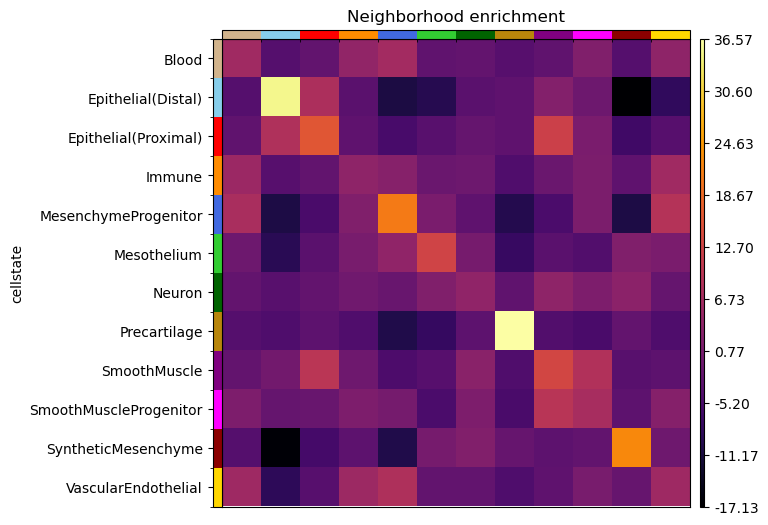

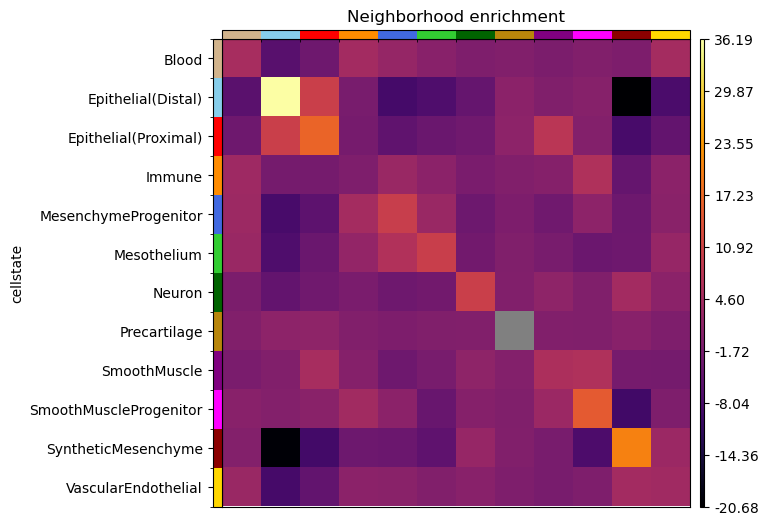

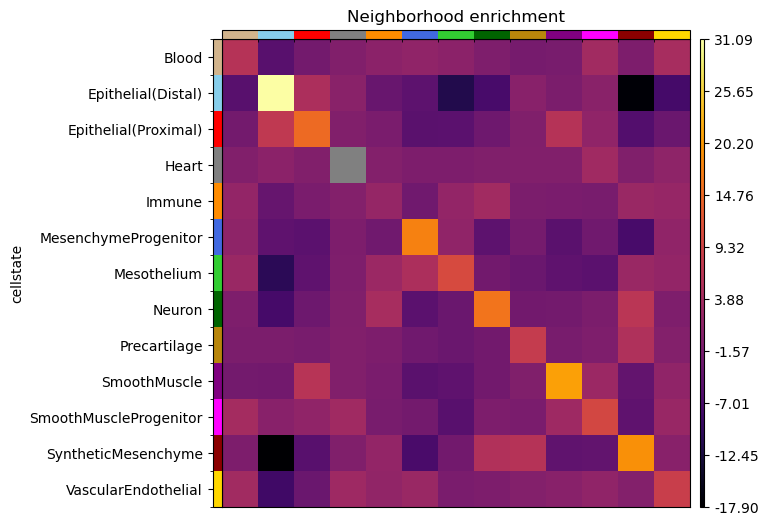

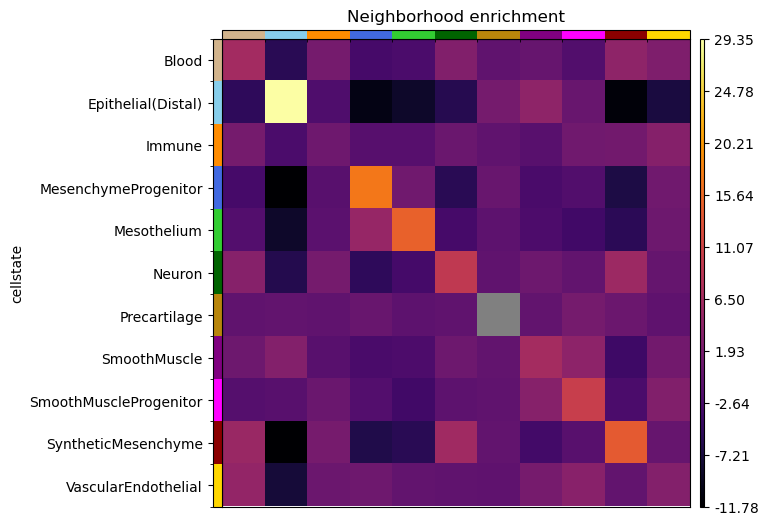

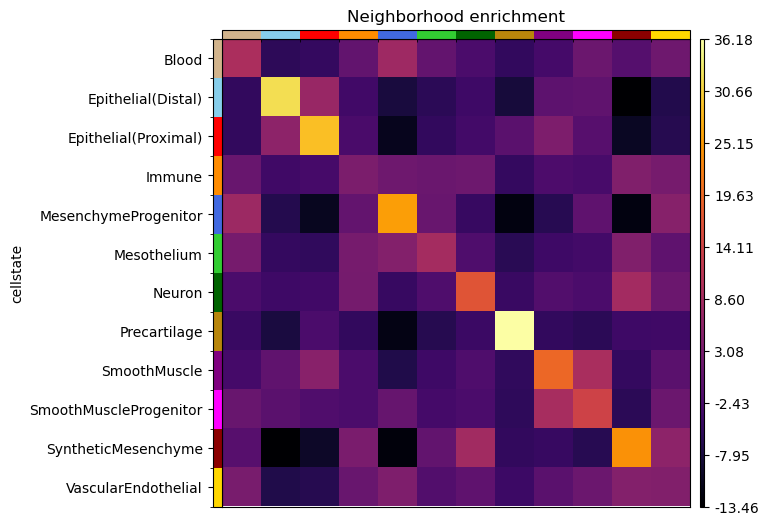

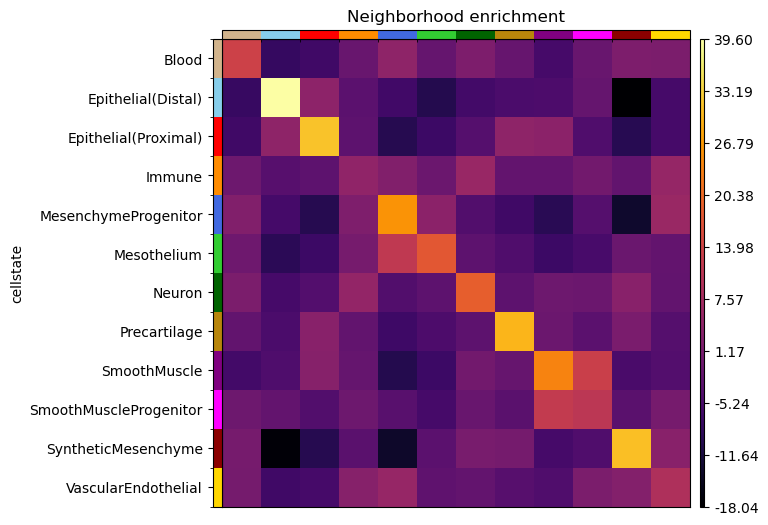

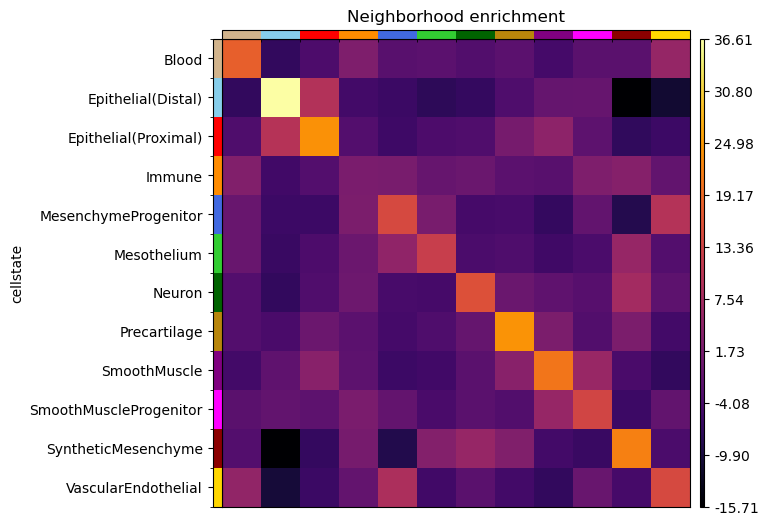

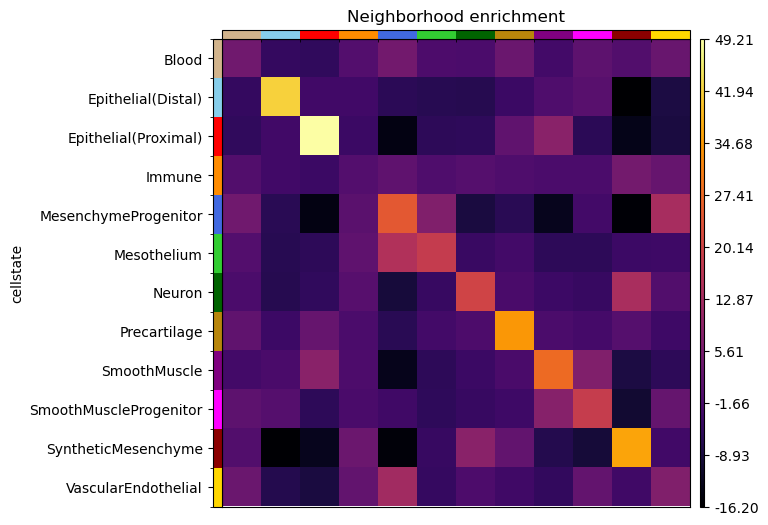

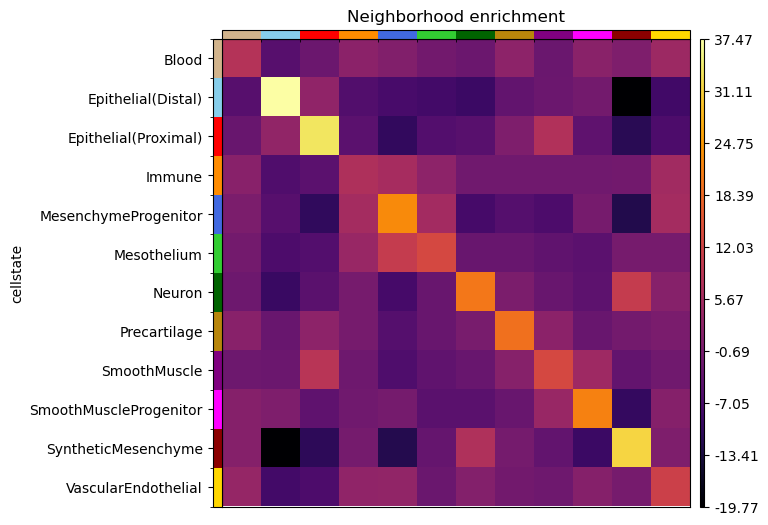

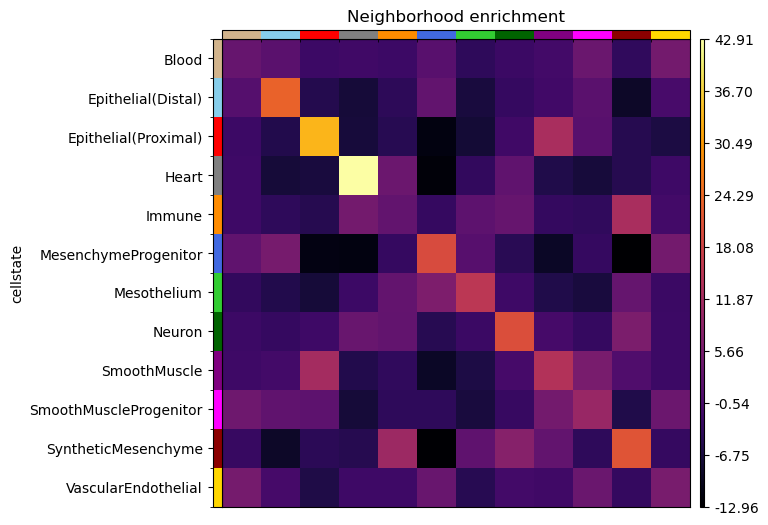

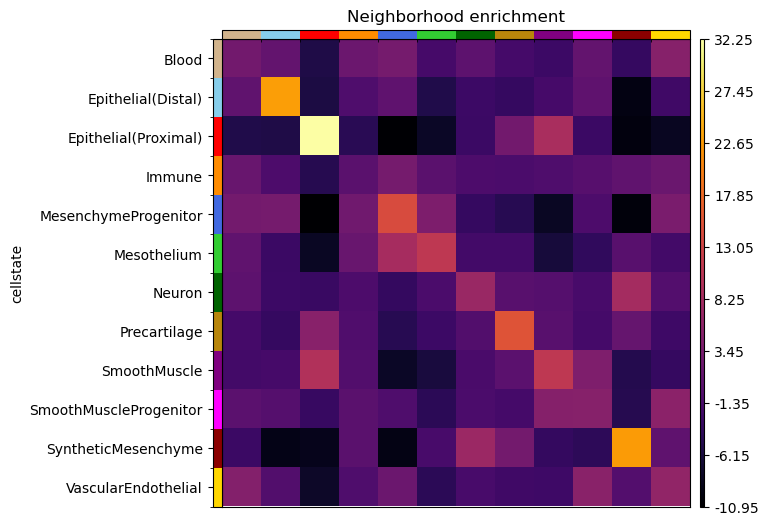

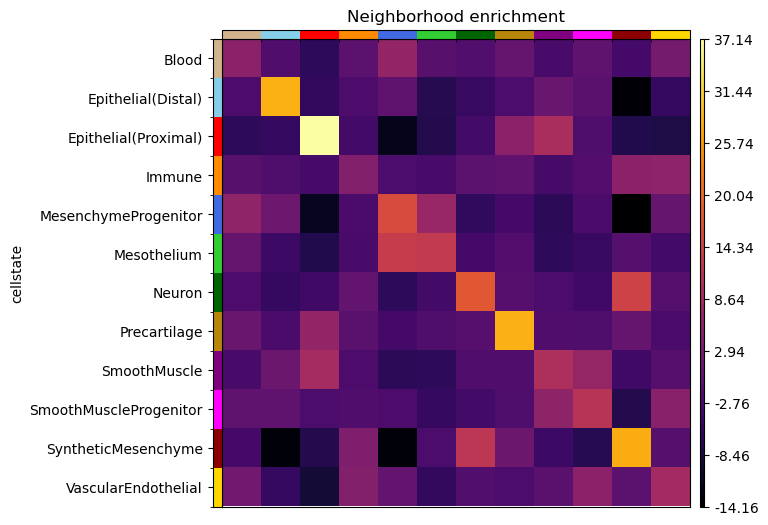

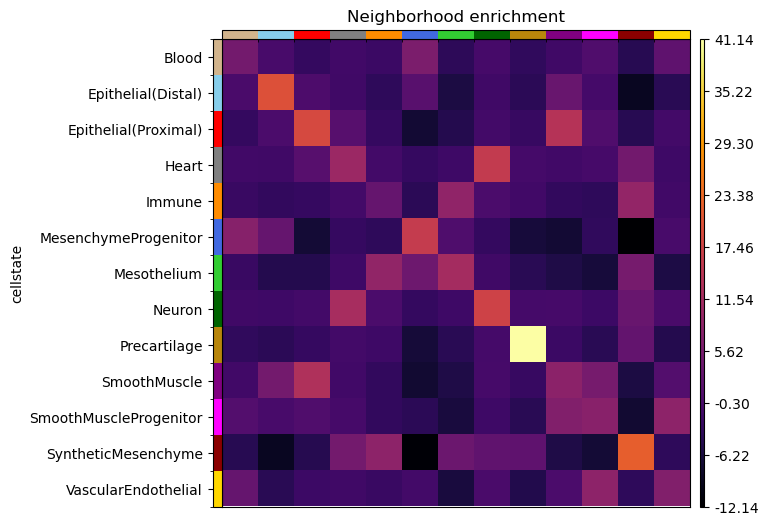

In [13]:
for exp in dbit_datasets:
    temp_adata = adata[(adata.obs['orig.ident'] == exp) & (adata.obs['cellstate'].isin(cell_order))].copy()
    sq.gr.spatial_neighbors(temp_adata, coord_type="generic", spatial_key="spatial")
    sq.gr.nhood_enrichment(temp_adata, cluster_key = 'cellstate')
    sq.pl.nhood_enrichment(temp_adata,
                           cluster_key="cellstate",
                           cmap="inferno",
                           figsize=(5, 5),
                        )

# Pull out the zscores of specific comparisons

In [25]:
cell_order = ['Blood', 'Epithelial(Distal)', 'Epithelial(Proximal)', 'Immune', 'MesenchymeProgenitor', 'Mesothelium', 'Neuron', 'Precartilage', 'SmoothMuscle', 'SmoothMuscleProgenitor', 'SyntheticMesenchyme', 'VascularEndothelial']

In [15]:
epithelial_comparisons = ['Distal_Distal', 'Distal_Proximal', 'Proximal_Proximal']
timepoints = ['E11.5', 'E12.5', 'E13.5']

epithelial_z_scores = pd.DataFrame(index = epithelial_comparisons, columns = dbit_datasets)
neuron_z_scores = pd.DataFrame(index = adata.obs['cellstate'].unique(), columns = dbit_datasets)

In [16]:
for exp in dbit_datasets:
    temp_adata = adata[(adata.obs['orig.ident'] == exp)].copy()
    sq.gr.spatial_neighbors(temp_adata, coord_type="generic", spatial_key="spatial")
    sq.gr.nhood_enrichment(temp_adata, cluster_key = 'cellstate')
    sq.pl.nhood_enrichment(temp_adata,
                           cluster_key="cellstate",
                           cmap="inferno",
                           figsize=(5, 5),
                        )

    count = 0
    Neuron_index = 0
    Distal_index = 0
    Proximal_index = 0
    for cellstate in temp_adata.obs['cellstate'].cat.categories:
        if cellstate == 'Neuron':
            Neuron_index = count
        elif cellstate == 'Epithelial(Distal)':
            Distal_index = count
        elif cellstate == 'Epithelial(Proximal)':
            Proximal_index = count
        count += 1

    if Distal_index != 0 and Proximal_index != 0:
        print(exp)
        epithelial_z_scores.loc['Distal_Distal', exp] = temp_adata.uns['cellstate_nhood_enrichment']['zscore'][Distal_index][Distal_index]
        epithelial_z_scores.loc['Distal_Proximal', exp] = temp_adata.uns['cellstate_nhood_enrichment']['zscore'][Distal_index][Proximal_index]
        epithelial_z_scores.loc['Proximal_Proximal', exp] = temp_adata.uns['cellstate_nhood_enrichment']['zscore'][Proximal_index][Proximal_index]

    count = 0
    for cellstate in temp_adata.obs['cellstate'].cat.categories:
        neuron_z_scores.loc[cellstate, exp] = temp_adata.uns['cellstate_nhood_enrichment']['zscore'][Neuron_index][count]
        count += 1

  0%|          | 0/1000 [00:00<?, ?/s]

E11lungR1


  0%|          | 0/1000 [00:00<?, ?/s]

/home/bklaw/anaconda3/envs/spatialdata/lib/python3.12/site-packages/squidpy/gr/_nhood.py:202: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


E11lungR2


...

E13lungR2


  0%|          | 0/1000 [00:00<?, ?/s]

E13lungR3


  0%|          | 0/1000 [00:00<?, ?/s]

E13lungR4


In [19]:
epithelial_z_scores.to_csv('Epithelial_nhood_enrichment.csv')
neuron_z_scores.to_csv('Neuron_nhood_enrichment.csv')